In [6]:
import pandas as pd

file_path = "01.KEPCO.parquet"

# Add engine='fastparquet' here!
df = pd.read_parquet(file_path, engine='fastparquet') 

print(df.head())

        date  floor  point space  id            datetime variable probe_id  \
0 2024-03-20      1      2  영업창구   3 2024-03-20 13:50:08      CO2      572   
1 2024-03-20      1      2  영업창구   3 2024-03-20 13:50:08      PMV     None   
2 2024-03-20      1      2  영업창구   3 2024-03-20 13:50:08      PPD     None   
3 2024-03-20      1      2  영업창구   3 2024-03-20 13:50:08       기류      555   
4 2024-03-20      1      2  영업창구   3 2024-03-20 13:50:08     상대습도      572   

        probe    value  unit  clo [m²K/W]  clo  met [W/m²]  met  
0  AirQuality  839.000   ppm        0.154  1.0        52.0  0.9  
1     Unknown   -0.200  None        0.154  1.0        52.0  0.9  
2     Unknown    5.800     %        0.154  1.0        52.0  0.9  
3  Turbulence    0.050   m/s        0.154  1.0        52.0  0.9  
4  AirQuality    0.257  None        0.154  1.0        52.0  0.9  


  eCPM Energy Model: KEPCO Real Data Analysis

[STEP 1] 데이터 처리 시작 (Processing Data)...
  [1/4] 에너지 사용량 데이터 로드 중 (Loading Energy Data)...
        -> 31개의 결측치 행 제거 완료 (Dropped empty energy rows).
  [2/4] PMV 센서 데이터 로드 중 (Loading PMV Data)...
  [3/4] 데이터 병합 중 (Merging Data)...
  [4/4] 결측치 보간 처리 중 (Handling missing Tint dates)...
  완료 (Done)! Total available days for training: 1985

[STEP 2] 특성 행렬 구성 (Building Features)...

[STEP 3] Ridge 회귀 학습 (Training Ridge Model)...

[추정 파라미터 (Estimated Parameters)]
  Eb (기저 사용량/Base Load) : 1542.47 kWh/day
  (Text-Tc)+  [외기 냉방]: -53.7121 kWh/℃
  (Text-Tint)+ [온도차 냉방]: 105.3787 kWh/℃
  (Th-Text)+  [외기 난방]: 114.5899 kWh/℃
  (Tint-Text)+ [온도차 난방]: -65.9001 kWh/℃

[모델 성능 (Model Performance)]
  R²      : 0.3949
  RMSE    : 409.31 kWh/day
  CV-RMSE : 30.95 % (ASHRAE 기준 ≤ 30%)

[STEP 4] 그래프 렌더링 (Rendering Visualization)...


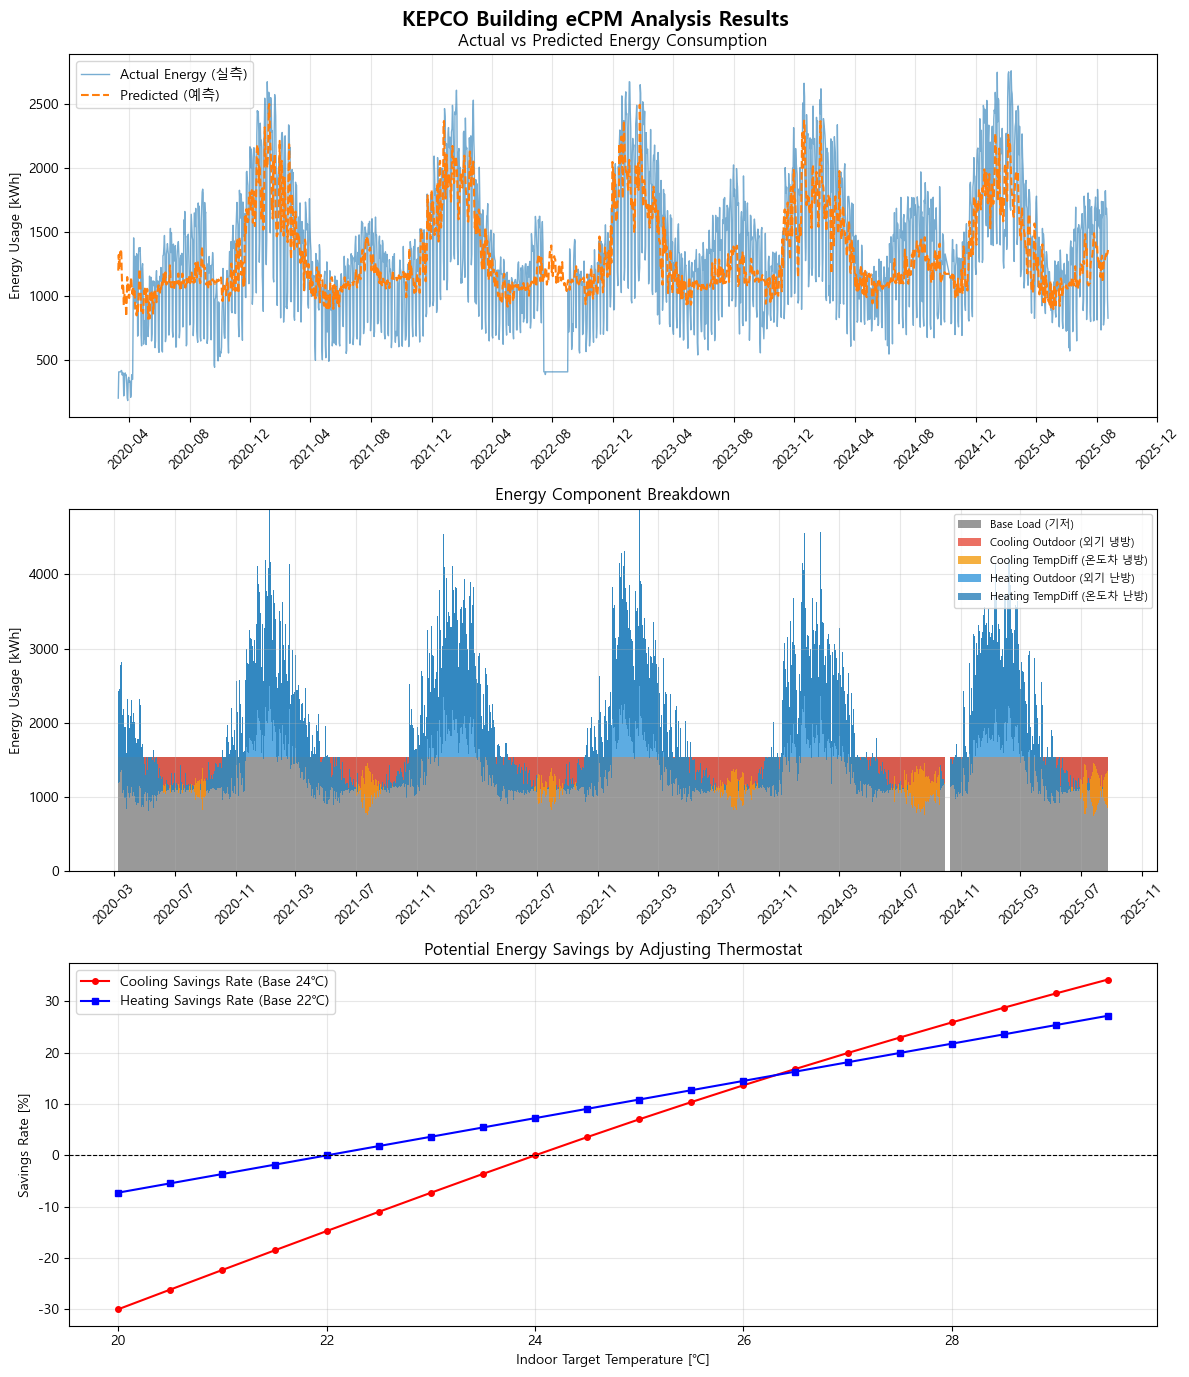

In [10]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore') # Suppress minor pandas warnings for clean output

# ── 한글 폰트 설정 (Korean Font Setup for Charts) ──────────────────
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    # Windows 환경 폰트 (Malgun Gothic)
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
except:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ══════════════════════════════════════════════════════════════
# 1. REAL DATA LOADING FUNCTION
# ══════════════════════════════════════════════════════════════

def load_kepco_real_data(energy_file, pmv_file):
    """
    Load and merge KEPCO Energy (Excel) and PMV (Parquet) data.
    """
    print("  [1/4] 에너지 사용량 데이터 로드 중 (Loading Energy Data)...")
    # 1. Load Energy Data
    df_energy = pd.read_excel(energy_file, parse_dates=['datetime'])
    df_energy = df_energy.rename(columns={
        'electricity_kWh': 'E',
        'temp_external': 'Text'
    })
    
    # Drop rows where target variable (Energy) is missing
    initial_rows = len(df_energy)
    df_energy = df_energy.dropna(subset=['E'])
    print(f"        -> {initial_rows - len(df_energy)}개의 결측치 행 제거 완료 (Dropped empty energy rows).")

    print("  [2/4] PMV 센서 데이터 로드 중 (Loading PMV Data)...")
    # 2. Load PMV Data (Using fastparquet or pyarrow engine)
    try:
        df_pmv = pd.read_parquet(pmv_file)
    except:
        df_pmv = pd.read_parquet(pmv_file, engine='fastparquet')
        
    # Filter for Temperature ("온도")
    df_temp = df_pmv[df_pmv['variable'] == '온도'].copy()
    
    # Calculate daily average indoor temperature
    df_temp['datetime'] = pd.to_datetime(df_temp['date'])
    daily_tint = df_temp.groupby('datetime')['value'].mean().reset_index()
    daily_tint = daily_tint.rename(columns={'value': 'Tint'})

    print("  [3/4] 데이터 병합 중 (Merging Data)...")
    # 3. Merge Energy and Daily PMV data
    df = pd.merge(df_energy[['datetime', 'E', 'Text']], daily_tint, on='datetime', how='left')
    
    # Set the index to datetime for time-series operations
    df = df.set_index('datetime')
    df = df.sort_index()

    print("  [4/4] 결측치 보간 처리 중 (Handling missing Tint dates)...")
    # 4. Handle dates where PMV sensor was off (Original fallback logic)
    if df["Tint"].isna().any():
        month = df.index.month
        # Set defaults based on season
        df.loc[df["Tint"].isna() & month.isin([6,7,8]), "Tint"] = 26.0
        df.loc[df["Tint"].isna() & month.isin([12,1,2]), "Tint"] = 22.0
        # Interpolate the rest (Spring/Fall)
        df["Tint"] = df["Tint"].interpolate(method="time")
        # Backfill/Forward-fill any remaining edge cases
        df["Tint"] = df["Tint"].bfill().ffill() 
        
    print(f"  완료 (Done)! Total available days for training: {len(df)}")
    return df


# ══════════════════════════════════════════════════════════════
# 2. eCPM MODEL FUNCTIONS (From Original Code)
# ══════════════════════════════════════════════════════════════

def build_features(df, Tc=18.0, Th=15.0):
    Text = df["Text"].values
    Tint = df["Tint"].values

    def hinge(x): return np.maximum(0, x)

    X = np.column_stack([
        hinge(Text - Tc),        # cc1: 외기 주도 냉방 (Outdoor Cooling)
        hinge(Text - Tint),      # cc2: 실내외 온도차 냉방 (Delta-T Cooling)
        hinge(Th  - Text),       # ch1: 외기 주도 난방 (Outdoor Heating)
        hinge(Tint - Text),      # ch2: 실내외 온도차 난방 (Delta-T Heating)
    ])
    y = df["E"].values

    feature_names = [
        "(Text-Tc)+  [외기 냉방]",
        "(Text-Tint)+ [온도차 냉방]",
        "(Th-Text)+  [외기 난방]",
        "(Tint-Text)+ [온도차 난방]",
    ]
    return X, y, feature_names


def train_ridge_model(X, y, feature_names, cv_splits=5):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    alphas = np.logspace(-4, 4, 50)
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    
    ridge_cv = RidgeCV(alphas=alphas, cv=tscv, scoring="neg_mean_squared_error")
    ridge_cv.fit(X_scaled, y)

    best_lambda = ridge_cv.alpha_
    model = Ridge(alpha=best_lambda)
    model.fit(X_scaled, y)

    coefs_original = model.coef_ / scaler.scale_
    intercept = model.intercept_ - np.sum(coefs_original * scaler.mean_)

    print(f"\n[추정 파라미터 (Estimated Parameters)]")
    print(f"  Eb (기저 사용량/Base Load) : {intercept:.2f} kWh/day")
    for name, c in zip(feature_names, coefs_original):
        print(f"  {name}: {c:.4f} kWh/℃")

    y_pred = model.predict(X_scaled)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    cv_rmse = rmse / np.mean(y) * 100
    
    print(f"\n[모델 성능 (Model Performance)]")
    print(f"  R²      : {r2:.4f}")
    print(f"  RMSE    : {rmse:.2f} kWh/day")
    print(f"  CV-RMSE : {cv_rmse:.2f} % (ASHRAE 기준 ≤ 30%)")

    return model, scaler, intercept, coefs_original, y_pred


def savings_rate(Text_arr, Tint_new, Tint_base, intercept, coefs, Tc=18.0, Th=15.0):
    def E_total(Tint_val):
        Tint = np.full_like(Text_arr, Tint_val)
        X = np.column_stack([
            np.maximum(0, Text_arr - Tc),
            np.maximum(0, Text_arr - Tint),
            np.maximum(0, Th - Text_arr),
            np.maximum(0, Tint - Text_arr),
        ])
        return intercept + X @ coefs

    E_base = E_total(Tint_base).sum()
    E_new  = E_total(Tint_new).sum()
    rate   = (1 - E_new / E_base) * 100
    return E_base, E_new, rate



def plot_results(df, y_pred, intercept, coefs, feature_names):
    fig, axes = plt.subplots(3, 1, figsize=(12, 14))
    fig.suptitle("KEPCO Building eCPM Analysis Results", fontsize=15, fontweight="bold")

    # 1. Actual vs Predicted
    ax = axes[0]
    ax.plot(df.index, df["E"], label="Actual Energy (실측)", alpha=0.6, lw=1)
    ax.plot(df.index, y_pred, label="Predicted (예측)", lw=1.5, linestyle="--")
    ax.set_ylabel("Energy Usage [kWh]")
    ax.set_title("Actual vs Predicted Energy Consumption")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Component Breakdown
    ax = axes[1]
    Text = df["Text"].values
    Tint = df["Tint"].values
    Tc, Th = 18.0, 15.0

    components = {
        "Base Load (기저)": np.full(len(df), intercept),
        "Cooling Outdoor (외기 냉방)":   coefs[0] * np.maximum(0, Text - Tc),
        "Cooling TempDiff (온도차 냉방)": coefs[1] * np.maximum(0, Text - Tint),
        "Heating Outdoor (외기 난방)":   coefs[2] * np.maximum(0, Th - Text),
        "Heating TempDiff (온도차 난방)": coefs[3] * np.maximum(0, Tint - Text),
    }
    bottom = np.zeros(len(df))
    colors = ["gray", "#e74c3c", "#f39c12", "#3498db", "#2980b9"]
    for (label, vals), color in zip(components.items(), colors):
        ax.bar(df.index, vals, bottom=bottom, label=label, alpha=0.8, color=color, width=1)
        bottom += vals
    ax.set_ylabel("Energy Usage [kWh]")
    ax.set_title("Energy Component Breakdown")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- NEW X-AXIS FORMATTING FOR MONTHS (Applies to Chart 1 and 2) ---
    for ax in [axes[0], axes[1]]:
        # Show a tick every 4 months to prevent overcrowding (e.g., Jan, May, Sep)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
        # Format as Year-Month (e.g., 2020-01)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        # Rotate the labels 45 degrees so they are easy to read
        ax.tick_params(axis='x', rotation=45) 
    # -------------------------------------------------------------------

    # 3. Savings Rate Simulator
    ax = axes[2]
    Tint_range = np.arange(20, 30, 0.5)
    savings_cool, savings_heat = [], []
    for Tval in Tint_range:
        mask_s = df.index.month.isin([6, 7, 8])
        if mask_s.sum() > 0:
            _, _, r = savings_rate(df["Text"][mask_s].values, Tval, 24.0, intercept, coefs)
            savings_cool.append(r)
        
        mask_w = df.index.month.isin([12, 1, 2])
        if mask_w.sum() > 0:
            _, _, r = savings_rate(df["Text"][mask_w].values, Tval, 22.0, intercept, coefs)
            savings_heat.append(r)

    ax.plot(Tint_range, savings_cool, "r-o", ms=4, label="Cooling Savings Rate (Base 24℃)")
    ax.plot(Tint_range, savings_heat, "b-s", ms=4, label="Heating Savings Rate (Base 22℃)")
    ax.axhline(0, color="k", lw=0.8, linestyle="--")
    ax.set_xlabel("Indoor Target Temperature [℃]")
    ax.set_ylabel("Savings Rate [%]")
    ax.set_title("Potential Energy Savings by Adjusting Thermostat")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":
    
    # !!! IMPORTANT: Update these file paths to match your exact computer directories !!!
    # Based on your screenshots, it looks something like this:
    ENERGY_FILE_PATH = "01.KEPCO-BEMS-day.xlsx"
    PMV_FILE_PATH = "01.KEPCO.parquet"

    print("=" * 55)
    print("  eCPM Energy Model: KEPCO Real Data Analysis")
    print("=" * 55)

    try:
        # 1. Load Real Data
        print("\n[STEP 1] 데이터 처리 시작 (Processing Data)...")
        df = load_kepco_real_data(ENERGY_FILE_PATH, PMV_FILE_PATH)
        
        # 2. Build Features
        print("\n[STEP 2] 특성 행렬 구성 (Building Features)...")
        X, y, feature_names = build_features(df, Tc=18.0, Th=15.0)

        # 3. Train Model
        print("\n[STEP 3] Ridge 회귀 학습 (Training Ridge Model)...")
        model, scaler, intercept, coefs, y_pred = train_ridge_model(X, y, feature_names, cv_splits=5)

        # 4. Show Chart
        print("\n[STEP 4] 그래프 렌더링 (Rendering Visualization)...")
        plot_results(df, y_pred, intercept, coefs, feature_names)

    except FileNotFoundError as e:
        print("\n[ERROR] 파일을 찾을 수 없습니다. 경로를 확인해주세요!")
        print(f"Error details: {e}")

  eCPM Energy Model: KEPCO Data (Final Version)

[STEP 1] 데이터 처리 시작 (Processing Data)...
  [1/4] 에너지 사용량 데이터 로드 중 (Loading Energy Data)...
  [2/4] PMV 센서 데이터 로드 중 (Loading PMV Data)...
  [3/4] 데이터 병합 중 (Merging Data)...
  [4/4] 결측치 및 주말 특성 처리 중 (Handling Missing & Weekends)...
  완료 (Done)! Total available days for training: 1985

[STEP 2] 특성 행렬 구성 (Building Features)...

[STEP 3] NNLS 회귀 학습 (Training Positive Constrained Model)...

[추정 파라미터 (Estimated Parameters - NNLS)]
  Eb (Weekday Base Load): 1109.2428 kWh/day
  Eb (Weekend Base Load): 467.6361 kWh/day
  (Text-Tint)+ [온도차 냉방]: 100.9855 kWh/℃
  (Tint-Text)+ [온도차 난방]: 35.3133 kWh/℃

[모델 성능 (Model Performance)]
  R²      : 0.5947
  RMSE    : 335.00 kWh/day
  CV-RMSE : 25.33 % (ASHRAE 기준 ≤ 30%)

[STEP 4] 그래프 렌더링 (Rendering Visualization)...


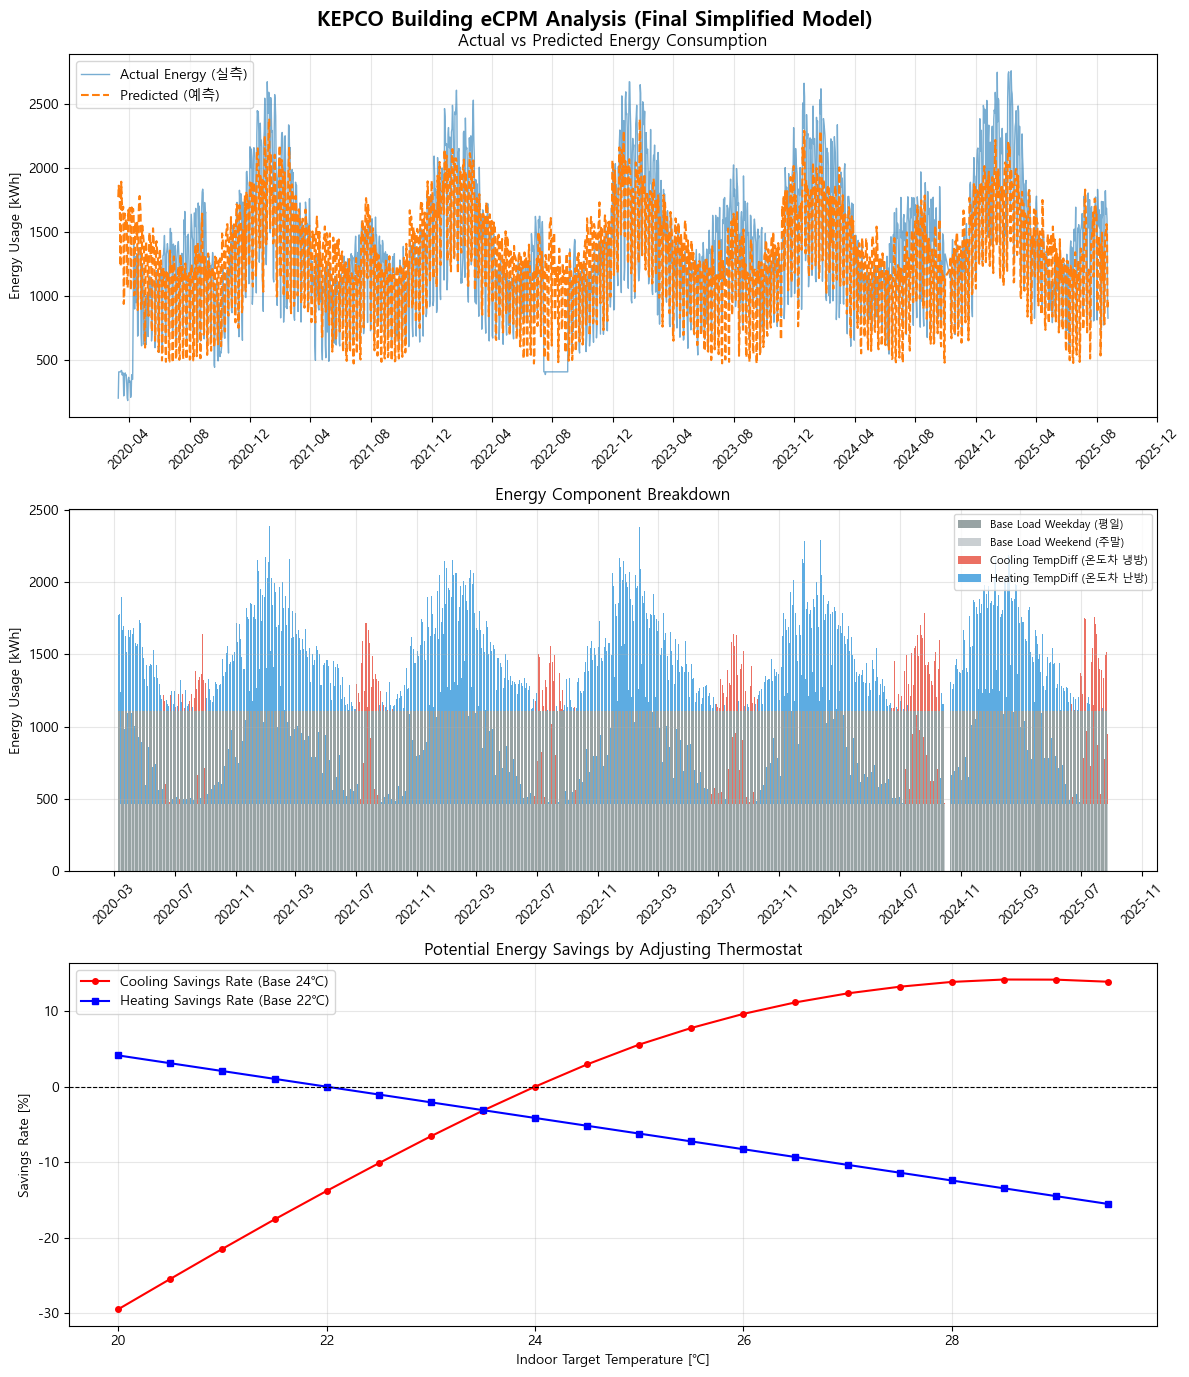

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Korean Font Setup) ���─────────────────
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
except:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ══════════════════════════════════════════════════════════════
# 1. REAL DATA LOADING
# ══════════════════════════════════════════════════════════════

def load_kepco_real_data(energy_file, pmv_file):
    print("  [1/4] 에너지 사용량 데이터 로드 중 (Loading Energy Data)...")
    df_energy = pd.read_excel(energy_file, parse_dates=['datetime'])
    df_energy = df_energy.rename(columns={'electricity_kWh': 'E', 'temp_external': 'Text'})
    df_energy = df_energy.dropna(subset=['E'])

    print("  [2/4] PMV 센서 데이터 로드 중 (Loading PMV Data)...")
    try:
        df_pmv = pd.read_parquet(pmv_file)
    except:
        df_pmv = pd.read_parquet(pmv_file, engine='fastparquet')
        
    df_temp = df_pmv[df_pmv['variable'] == '온도'].copy()
    df_temp['datetime'] = pd.to_datetime(df_temp['date'])
    daily_tint = df_temp.groupby('datetime')['value'].mean().reset_index()
    daily_tint = daily_tint.rename(columns={'value': 'Tint'})

    print("  [3/4] 데이터 병합 중 (Merging Data)...")
    df = pd.merge(df_energy[['datetime', 'E', 'Text']], daily_tint, on='datetime', how='left')
    df = df.set_index('datetime').sort_index()

    print("  [4/4] 결측치 및 주말 특성 처리 중 (Handling Missing & Weekends)...")
    if df["Tint"].isna().any():
        month = df.index.month
        df.loc[df["Tint"].isna() & month.isin([6,7,8]), "Tint"] = 26.0
        df.loc[df["Tint"].isna() & month.isin([12,1,2]), "Tint"] = 22.0
        df["Tint"] = df["Tint"].interpolate(method="time").bfill().ffill() 
        
    df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(float)
    df['is_weekday'] = 1.0 - df['is_weekend']
        
    print(f"  완료 (Done)! Total available days for training: {len(df)}")
    return df


# ══════════════════════════════════════════════════════════════
# 2. UPGRADED eCPM MODEL (4-Variable NNLS)
# ══════════════════════════════════════════════════════════════

def build_features(df):
    Text = df["Text"].values
    Tint = df["Tint"].values
    is_weekday = df["is_weekday"].values
    is_weekend = df["is_weekend"].values

    def hinge(x): return np.maximum(0, x)

    X = np.column_stack([
        is_weekday,              # coefs[0]: Eb_weekday
        is_weekend,              # coefs[1]: Eb_weekend
        hinge(Text - Tint),      # coefs[2]: Delta-T Cooling
        hinge(Tint - Text),      # coefs[3]: Delta-T Heating
    ])
    y = df["E"].values

    feature_names = [
        "Eb (Weekday Base Load)",
        "Eb (Weekend Base Load)",
        "(Text-Tint)+ [온도차 냉방]",
        "(Tint-Text)+ [온도차 난방]",
    ]
    return X, y, feature_names


def train_nnls_model(X, y, feature_names):
    model = LinearRegression(positive=True, fit_intercept=False)
    model.fit(X, y)
    coefs = model.coef_

    print(f"\n[추정 파라미터 (Estimated Parameters - NNLS)]")
    for name, c in zip(feature_names, coefs):
        unit = "kWh/day" if "Base Load" in name else "kWh/℃"
        print(f"  {name}: {c:.4f} {unit}")

    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    cv_rmse = rmse / np.mean(y) * 100
    
    print(f"\n[모델 성능 (Model Performance)]")
    print(f"  R²      : {r2:.4f}")
    print(f"  RMSE    : {rmse:.2f} kWh/day")
    print(f"  CV-RMSE : {cv_rmse:.2f} % (ASHRAE 기준 ≤ 30%)")

    return model, coefs, y_pred


def savings_rate(df_subset, Tint_new, Tint_base, coefs):
    # FIXED: Exactly 4 columns to match the 4 coefficients!
    Text_arr = df_subset["Text"].values
    is_wkday = df_subset["is_weekday"].values
    is_wkend = df_subset["is_weekend"].values

    def E_total(Tint_val):
        Tint = np.full_like(Text_arr, Tint_val)
        X = np.column_stack([
            is_wkday,
            is_wkend,
            np.maximum(0, Text_arr - Tint),
            np.maximum(0, Tint - Text_arr),
        ])
        return X @ coefs

    E_base = E_total(Tint_base).sum()
    E_new  = E_total(Tint_new).sum()
    rate   = (1 - E_new / E_base) * 100 if E_base > 0 else 0
    return E_base, E_new, rate


def plot_results(df, y_pred, coefs, feature_names):
    fig, axes = plt.subplots(3, 1, figsize=(12, 14))
    fig.suptitle("KEPCO Building eCPM Analysis (Final Simplified Model)", fontsize=15, fontweight="bold")

    # 1. Actual vs Predicted
    ax = axes[0]
    ax.plot(df.index, df["E"], label="Actual Energy (실측)", alpha=0.6, lw=1)
    ax.plot(df.index, y_pred, label="Predicted (예측)", lw=1.5, linestyle="--", color="#ff7f0e")
    ax.set_ylabel("Energy Usage [kWh]")
    ax.set_title("Actual vs Predicted Energy Consumption")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Component Breakdown
    ax = axes[1]
    Text = df["Text"].values
    Tint = df["Tint"].values

    components = {
        "Base Load Weekday (평일)": coefs[0] * df["is_weekday"].values,
        "Base Load Weekend (주말)": coefs[1] * df["is_weekend"].values,
        "Cooling TempDiff (온도차 냉방)": coefs[2] * np.maximum(0, Text - Tint),
        "Heating TempDiff (온도차 난방)": coefs[3] * np.maximum(0, Tint - Text),
    }
    
    bottom = np.zeros(len(df))
    colors = ["#7f8c8d", "#bdc3c7", "#e74c3c", "#3498db"] 
    for (label, vals), color in zip(components.items(), colors):
        ax.bar(df.index, vals, bottom=bottom, label=label, alpha=0.8, color=color, width=1)
        bottom += vals
        
    ax.set_ylabel("Energy Usage [kWh]")
    ax.set_title("Energy Component Breakdown")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

    # X-Axis Month Formatting
    for ax_idx in [axes[0], axes[1]]:
        ax_idx.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
        ax_idx.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax_idx.tick_params(axis='x', rotation=45)

    # 3. Savings Rate Simulator
    ax = axes[2]
    Tint_range = np.arange(20, 30, 0.5)
    savings_cool, savings_heat = [], []
    
    for Tval in Tint_range:
        mask_s = df.index.month.isin([6, 7, 8])
        if mask_s.sum() > 0:
            _, _, r = savings_rate(df[mask_s], Tval, 24.0, coefs)
            savings_cool.append(r)
        else:
            savings_cool.append(0)
            
        mask_w = df.index.month.isin([12, 1, 2])
        if mask_w.sum() > 0:
            _, _, r = savings_rate(df[mask_w], Tval, 22.0, coefs)
            savings_heat.append(r)
        else:
            savings_heat.append(0)

    ax.plot(Tint_range, savings_cool, "r-o", ms=4, label="Cooling Savings Rate (Base 24℃)")
    ax.plot(Tint_range, savings_heat, "b-s", ms=4, label="Heating Savings Rate (Base 22℃)")
    ax.axhline(0, color="k", lw=0.8, linestyle="--")
    ax.set_xlabel("Indoor Target Temperature [℃]")
    ax.set_ylabel("Savings Rate [%]")
    ax.set_title("Potential Energy Savings by Adjusting Thermostat")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":
    
    ENERGY_FILE_PATH = "01.KEPCO-BEMS-day.xlsx"
    PMV_FILE_PATH = "01.KEPCO.parquet"

    print("=" * 55)
    print("  eCPM Energy Model: KEPCO Data (Final Version)")
    print("=" * 55)

    try:
        print("\n[STEP 1] 데이터 처리 시작 (Processing Data)...")
        df = load_kepco_real_data(ENERGY_FILE_PATH, PMV_FILE_PATH)
        
        print("\n[STEP 2] 특성 행렬 구성 (Building Features)...")
        X, y, feature_names = build_features(df)

        print("\n[STEP 3] NNLS 회귀 학습 (Training Positive Constrained Model)...")
        model, coefs, y_pred = train_nnls_model(X, y, feature_names)

        print("\n[STEP 4] 그래프 렌더링 (Rendering Visualization)...")
        plot_results(df, y_pred, coefs, feature_names)

    except FileNotFoundError as e:
        print("\n[ERROR] 파일을 찾을 수 없습니다. 경로를 확인해주세요!")
        print(f"Error details: {e}")